<a href="https://colab.research.google.com/github/baoan056788/THDeppLearning/blob/main/Buoi3_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import keras
from keras.layers import Conv2D, Dense, MaxPool2D, Flatten
from keras.models import Sequential
from keras import Input
#data visualization packages
import matplotlib.pyplot as plt

In [ ]:
import pandas as pd
import numpy as np

# Đường dẫn dữ liệu MNIST có sẵn trong Google Colab
mnist_train = "/content/sample_data/mnist_train_small.csv"
mnist_test = "/content/sample_data/mnist_test.csv"

# Đọc dữ liệu
# header=None để không làm mất dòng đầu tiên
df_train = pd.read_csv(mnist_train, header=None)
df_test = pd.read_csv(mnist_test, header=None)

print("Train dataframe:", df_train.shape)
print("Test dataframe:", df_test.shape)

# Cột 0 là nhãn, các cột còn lại là pixel
X_train = df_train.iloc[:, 1:].values
y_train = df_train.iloc[:, 0].values

X_test = df_test.iloc[:, 1:].values
y_test = df_test.iloc[:, 0].values

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Train dataframe: (20000, 785)
Test dataframe: (10000, 785)
X_train: (20000, 784)
y_train: (20000,)
X_test: (10000, 784)
y_test: (10000,)


In [ ]:
num_classes = 10
input_shape = (28, 28, 1)

# Chuẩn hóa pixel về [0, 1]
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Reshape từ vector 784 thành ảnh 28x28x1
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("Number of classes:", len(np.unique(y_train)))
print("Classes:", np.unique(y_train))
print("First 5 labels:", y_train[:5])

X_train: (20000, 28, 28, 1)
X_test: (10000, 28, 28, 1)
Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]
First 5 labels: [6 5 7 9 5]


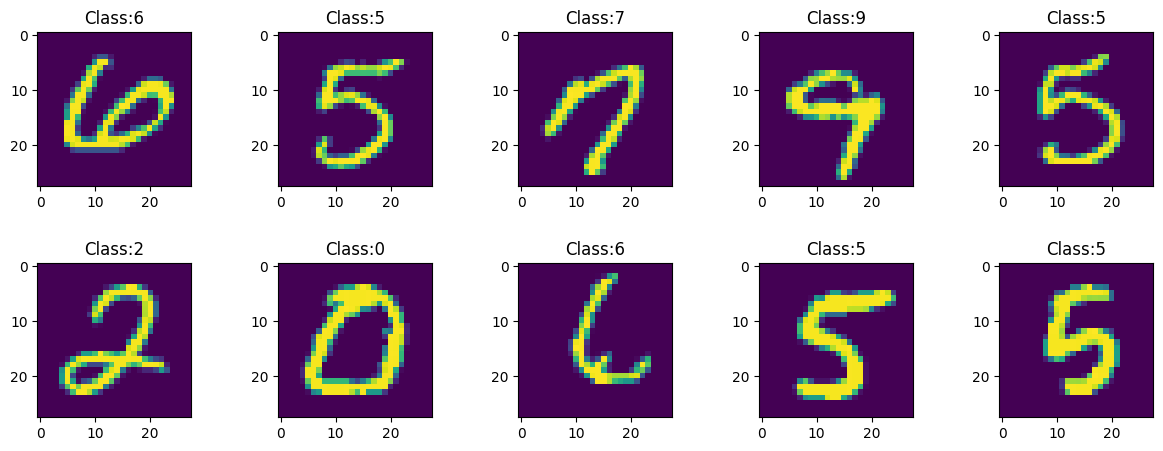

In [ ]:
#Data visualization
fig, axes = plt.subplots(nrows=2, ncols=5,figsize=(15, 5))
ax = axes.ravel()
for i in range(10):
  ax[i].imshow(X_train[i].reshape(28, 28))
  ax[i].title.set_text('Class:'+str(y_train[i]))
plt.subplots_adjust(hspace=0.5)
plt.show()

In [ ]:
y_train = keras. utils.to_categorical(y_train, num_classes)
y_test = keras.utils. to_categorical(y_test, num_classes)

In [ ]:
model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(units=10, activation='softmax'))
model. summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy' ])
model_fit = model.fit(X_train, y_train, batch_size=128, epochs=15, validation_split=0.1, verbose=1)

Epoch 1/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 14s 83ms/step - accuracy: 0.1093 - loss: 2.3018 - val_accuracy: 0.1220 - val_loss: 2.2995
Epoch 2/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 21s 90ms/step - accuracy: 0.1111 - loss: 2.3014 - val_accuracy: 0.1220 - val_loss: 2.2998
Epoch 3/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 21s 92ms/step - accuracy: 0.1111 - loss: 2.3014 - val_accuracy: 0.1220 - val_loss: 2.3000
Epoch 4/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 21s 94ms/step - accuracy: 0.1111 - loss: 2.3012 - val_accuracy: 0.1220 - val_loss: 2.2996
Epoch 5/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 20s 92ms/step - accuracy: 0.1111 - loss: 2.3012 - val_accuracy: 0.1220 - val_loss: 2.2997
Epoch 6/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 12s 86ms/step - accuracy: 0.1111 - loss: 2.3012 - val_accuracy: 0.1220 - val_loss: 2.2995
Epoch 7/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 19s 78ms/step - accuracy: 0.1111 - loss: 2.3011 - val_accuracy: 0.1220 - val_loss: 2.2995
Epoch 8/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 12s 82ms/step - accuracy: 0.1111 - loss: 2.3011 - 

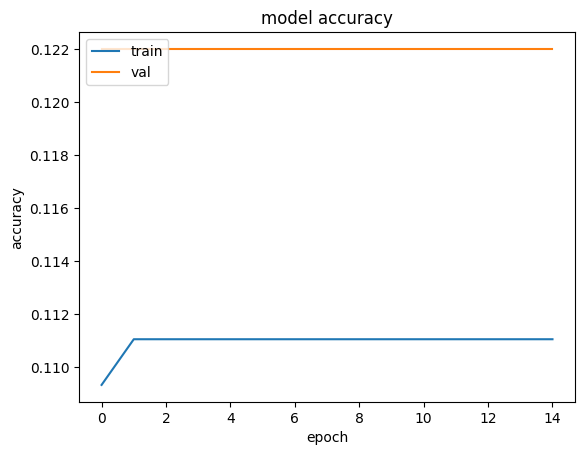

In [ ]:
plt.plot(model_fit.history['accuracy' ])
plt.plot(model_fit.history['val_accuracy' ])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt. legend(['train', 'val'], loc='upper left')
plt.show()

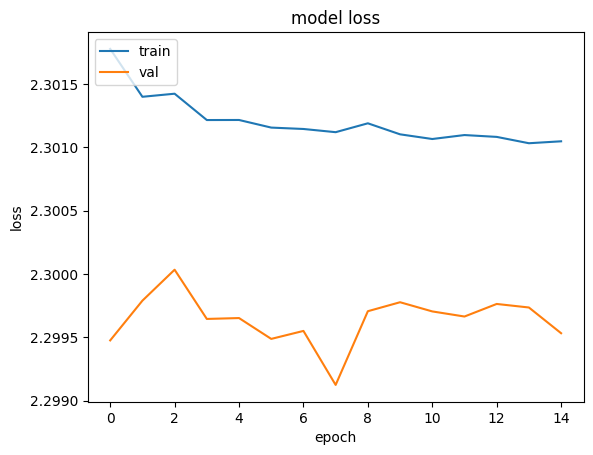

In [ ]:
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [ ]:
score = model.evaluate(X_test, y_test, verbose=2)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

313/313 - 3s - 9ms/step - accuracy: 0.1135 - loss: 2.3013
Test loss: 2.3012826442718506
Test accuracy: 0.11349999904632568


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
[[0.09800669 0.11055191 0.0992224  0.10196631 0.09642349 0.08875446
  0.10294556 0.10511512 0.09578393 0.10123013]]
1 7


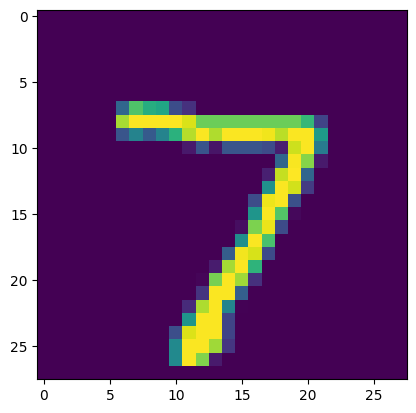

In [ ]:
predict = model.predict(X_test[:1])
print(predict)
print(np.argmax(predict), np.argmax(y_test[0]))
plt.imshow(X_test[:1].reshape(28, 28))
plt.show()

In [ ]:
model.save("cnn.keras")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
[[0.09999996 0.10000008 0.09999994 0.09999975 0.09999975 0.09999998
  0.10000018 0.1000001  0.10000017 0.10000011]]
6 2


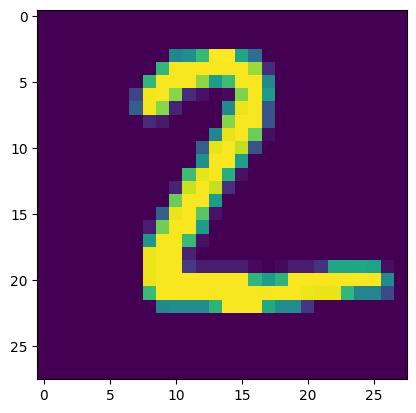

In [ ]:
model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(units=10, activation='softmax'))
model.load_weights('cnn.keras')

predict = model.predict(X_test[1:2])
print(predict)
print(np.argmax(predict), np.argmax(y_test[1]))
plt.imshow(X_test[1:2].reshape(28, 28))
plt.show()

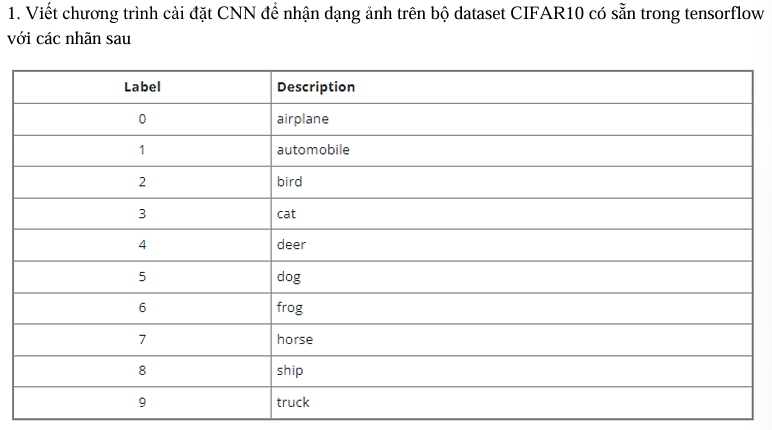

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

SEED = 42
tf.keras.utils.set_random_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU: []


In [ ]:
# Load CIFAR-10 có sẵn trong TensorFlow/Keras
(X_train_full, y_train_full), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Tên các lớp
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

print("X_train_full:", X_train_full.shape)
print("y_train_full:", y_train_full.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
X_train_full: (50000, 32, 32, 3)
y_train_full: (50000, 1)
X_test: (10000, 32, 32, 3)
y_test: (10000, 1)


In [ ]:
# Chuyển label từ shape (N, 1) thành (N,)
y_train_full = y_train_full.reshape(-1)
y_test = y_test.reshape(-1)

# Chuẩn hóa pixel từ [0, 255] về [0, 1]
X_train_full = X_train_full.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Chia train thành train/validation
# 45,000 ảnh train, 5,000 ảnh validation
X_train = X_train_full[:45000]
y_train = y_train_full[:45000]

X_val = X_train_full[45000:]
y_val = y_train_full[45000:]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (45000, 32, 32, 3)
y_train: (45000,)
X_val: (5000, 32, 32, 3)
y_val: (5000,)
X_test: (10000, 32, 32, 3)
y_test: (10000,)


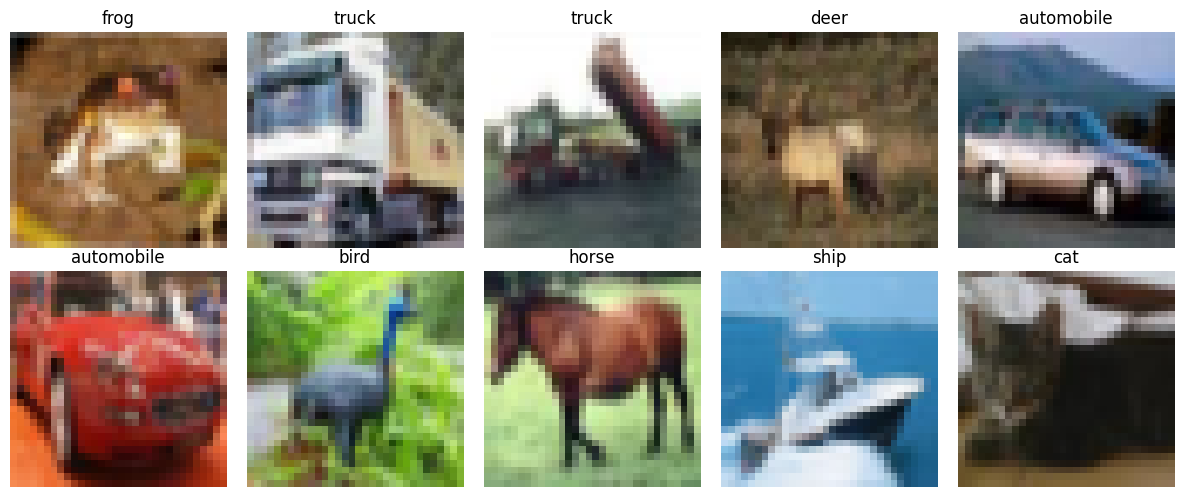

In [ ]:
plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
BATCH_SIZE = 64
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))

train_ds = (
    train_ds
    .shuffle(buffer_size=10000, seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    val_ds
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    test_ds
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

In [ ]:
num_classes = 10
input_shape = (32, 32, 3)

weight_decay = 1e-4

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.08, 0.08),
], name="data_augmentation")


def build_cifar10_cnn():
    inputs = layers.Input(shape=input_shape)

    # Data augmentation chỉ hoạt động khi training=True
    x = data_augmentation(inputs)

    # Block 1
    x = layers.Conv2D(
        32, (3, 3),
        padding="same",
        kernel_regularizer=regularizers.l2(weight_decay)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(
        32, (3, 3),
        padding="same",
        kernel_regularizer=regularizers.l2(weight_decay)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = layers.Dropout(0.25)(x)

    # Block 2
    x = layers.Conv2D(
        64, (3, 3),
        padding="same",
        kernel_regularizer=regularizers.l2(weight_decay)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(
        64, (3, 3),
        padding="same",
        kernel_regularizer=regularizers.l2(weight_decay)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = layers.Dropout(0.30)(x)

    # Block 3
    x = layers.Conv2D(
        128, (3, 3),
        padding="same",
        kernel_regularizer=regularizers.l2(weight_decay)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(
        128, (3, 3),
        padding="same",
        kernel_regularizer=regularizers.l2(weight_decay)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = layers.Dropout(0.35)(x)

    # Classification head
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=regularizers.l2(weight_decay)
    )(x)
    x = layers.Dropout(0.40)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs, name="CIFAR10_CNN")
    return model


model = build_cifar10_cnn()
model.summary()

Model: "CIFAR10_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 306,602 (1.17 MB)

 Trainable params: 305,706 (1.17 MB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
loss="sparse_categorical_crossentropy"

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
callbacks = [
    ModelCheckpoint(
        filepath="best_cifar10_cnn.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    EarlyStopping(
        monitor="val_accuracy",
        patience=10,
        restore_best_weights=True,
        mode="max",
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 562ms/step - accuracy: 0.3662 - loss: 1.7537
Epoch 1: val_accuracy improved from None to 0.41720, saving model to best_cifar10_cnn.keras

Epoch 1: finished saving model to best_cifar10_cnn.keras
704/704 ━━━━━━━━━━━━━━━━━━━━ 404s 574ms/step - accuracy: 0.4099 - loss: 1.6548 - val_accuracy: 0.4172 - val_loss: 1.8173 - learning_rate: 0.0010
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 540ms/step - accuracy: 0.4933 - loss: 1.4536
Epoch 2: val_accuracy improved from 0.41720 to 0.52520, saving model to best_cifar10_cnn.keras

Epoch 2: finished saving model to best_cifar10_cnn.keras
704/704 ━━━━━━━━━━━━━━━━━━━━ 427s 553ms/step - accuracy: 0.5081 - loss: 1.4207 - val_accuracy: 0.5252 - val_loss: 1.3492 - learning_rate: 0.0010
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 538ms/step - accuracy: 0.5477 - loss: 1.3370
Epoch 3: val_accuracy did not improve from 0.52520
704/704 ━━━━━━━━━━━━━━━━━━━━ 440s 551ms/step - accuracy: 0.5530 - loss: 1.3213 - val_accurac

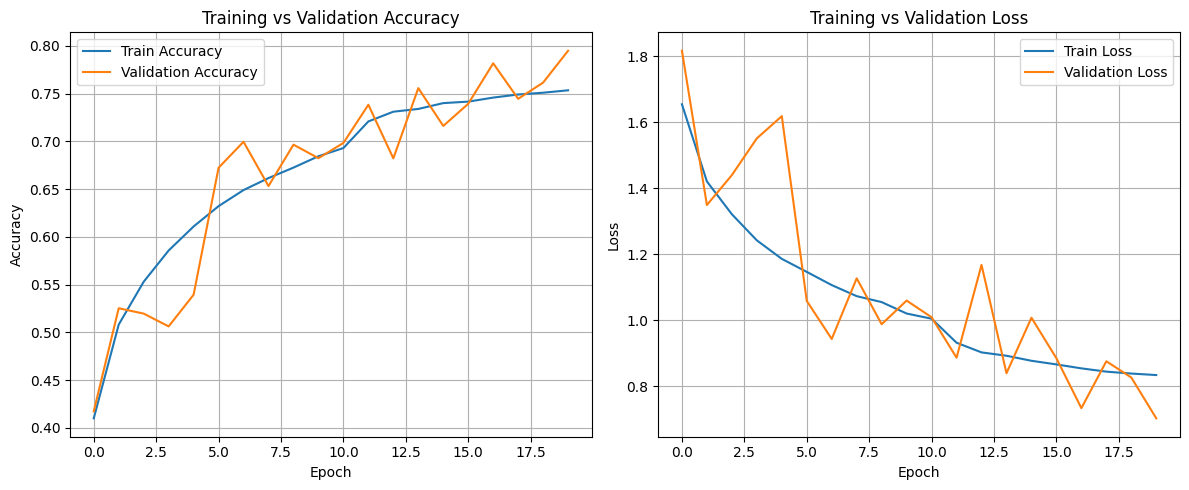

In [ ]:
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 125ms/step - accuracy: 0.7862 - loss: 0.7384
Test Loss: 0.7383560538291931
Test Accuracy: 0.7861999869346619


In [ ]:
y_pred_prob = model.predict(test_ds)
y_pred = np.argmax(y_pred_prob, axis=1)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

157/157 ━━━━━━━━━━━━━━━━━━━━ 27s 166ms/step
Classification Report:
              precision    recall  f1-score   support

    airplane       0.88      0.69      0.77      1000
  automobile       0.86      0.92      0.89      1000
        bird       0.73      0.70      0.71      1000
         cat       0.68      0.65      0.66      1000
        deer       0.77      0.74      0.75      1000
         dog       0.79      0.69      0.74      1000
        frog       0.70      0.88      0.78      1000
       horse       0.84      0.83      0.84      1000
        ship       0.88      0.86      0.87      1000
       truck       0.76      0.91      0.83      1000

    accuracy                           0.79     10000
   macro avg       0.79      0.79      0.78     10000
weighted avg       0.79      0.79      0.78     10000



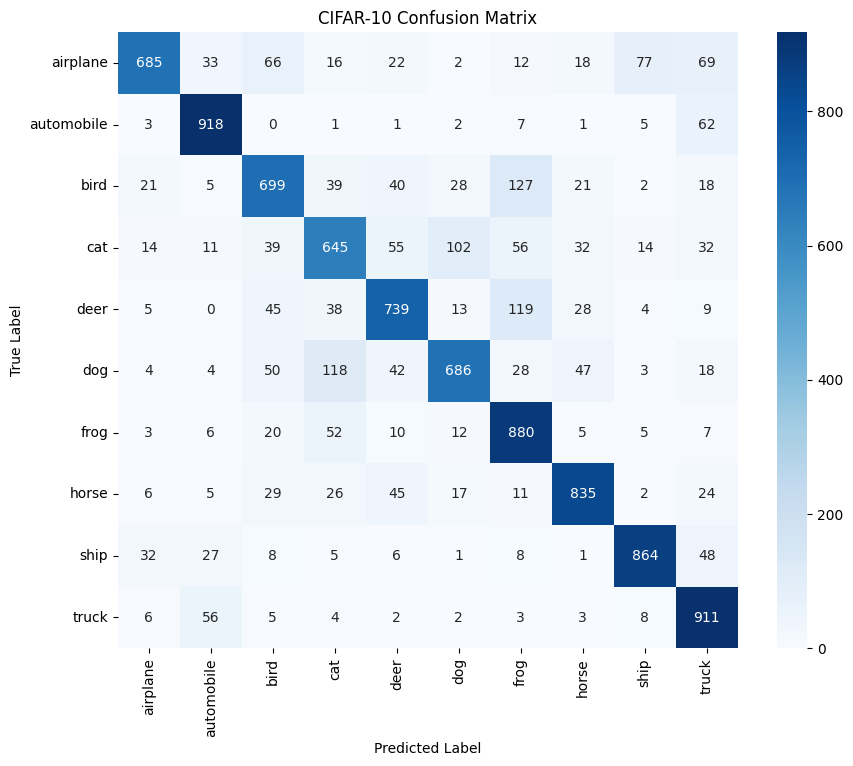

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("CIFAR-10 Confusion Matrix")
plt.show()

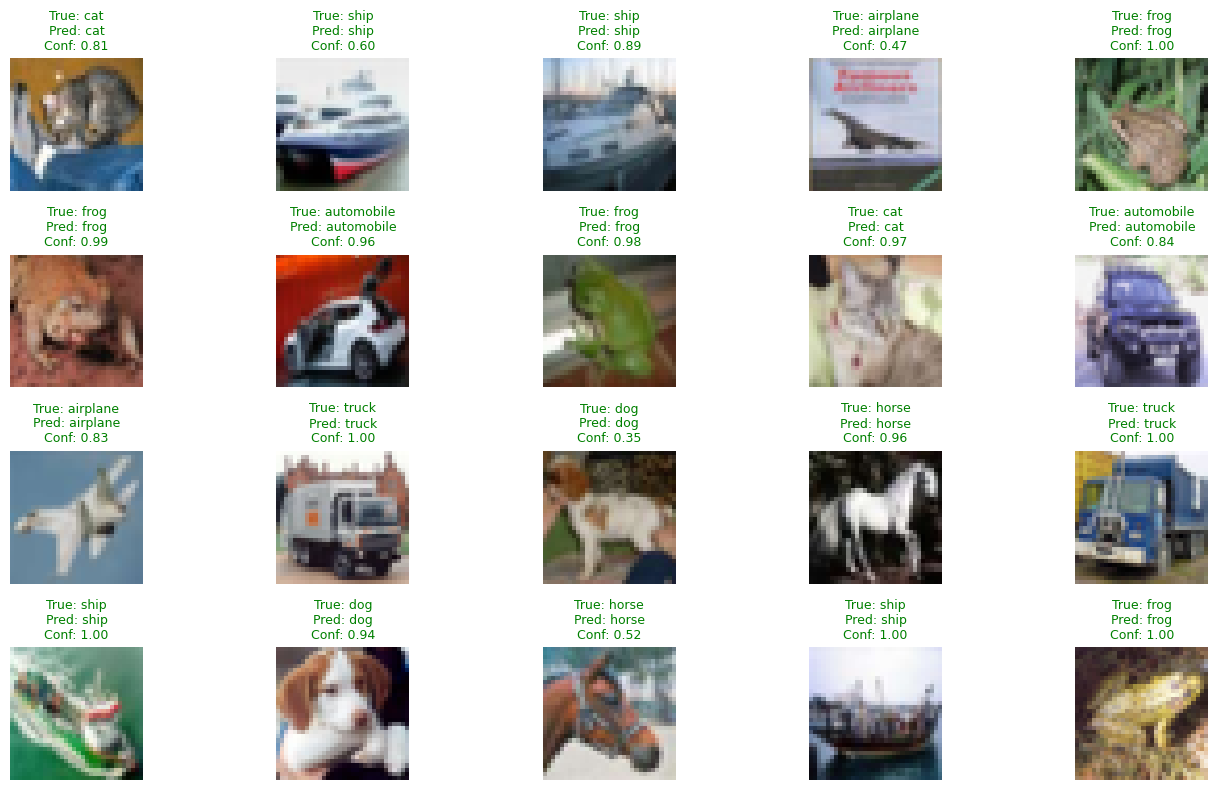

In [ ]:
plt.figure(figsize=(14, 8))

for i in range(20):
    plt.subplot(4, 5, i + 1)

    img = X_test[i]
    true_label = y_test[i]
    pred_label = y_pred[i]
    confidence = np.max(y_pred_prob[i])

    plt.imshow(img)

    title = f"True: {class_names[true_label]}\nPred: {class_names[pred_label]}\nConf: {confidence:.2f}"

    if true_label == pred_label:
        color = "green"
    else:
        color = "red"

    plt.title(title, color=color, fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
model.save("cifar10_cnn.keras")
print("Đã lưu mô hình: cifar10_cnn.keras")

Đã lưu mô hình: cifar10_cnn.keras


In [ ]:
loaded_model = tf.keras.models.load_model("cifar10_cnn.keras", compile=False)

loaded_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

loaded_model.evaluate(test_ds)

157/157 ━━━━━━━━━━━━━━━━━━━━ 19s 116ms/step - accuracy: 0.7862 - loss: 0.7384


[0.7383560538291931, 0.7861999869346619]

2. Hãy viết chương trình cài đặt CNN để nhận dạng ảnh Cat hoặc Dog. Dữ liệu do giảng viên cung cấp

In [ ]:
import os
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: []


In [ ]:
DATA_ROOT = Path("/content/dataset")   # SỬA ĐƯỜNG DẪN Ở ĐÂY

IMG_SIZE = (150, 150)
BATCH_SIZE = 32
NUM_CLASSES = 2

print("DATA_ROOT:", DATA_ROOT)
print("Exists:", DATA_ROOT.exists())

if DATA_ROOT.exists():
    print("Subfolders:", os.listdir(DATA_ROOT))

DATA_ROOT: /content/dataset
Exists: False


In [ ]:
from pathlib import Path
import os

# Nếu Kaggle Notebook chưa có kagglehub thì cài
try:
    import kagglehub
except ImportError:
    !pip install -q kagglehub
    import kagglehub


# =========================
# DATASET KAGGLE PUBLIC
# =========================

DATASET_HANDLE = "samuelcortinhas/cats-and-dogs-image-classification"

DATA_ROOT = Path(
    kagglehub.dataset_download(DATASET_HANDLE)
)

IMG_SIZE = (150, 150)
BATCH_SIZE = 32
NUM_CLASSES = 2

print("DATASET_HANDLE:", DATASET_HANDLE)
print("DATA_ROOT:", DATA_ROOT)
print("Exists:", DATA_ROOT.exists())

if DATA_ROOT.exists():
    print("Nội dung DATA_ROOT:")
    for item in os.listdir(DATA_ROOT):
        print("-", item)
else:
    raise FileNotFoundError("Không tải/gắn được dataset từ Kaggle.")

100%|██████████| 64.4M/64.4M [00:00<00:00, 104MB/s]

Extracting files...


DATASET_HANDLE: samuelcortinhas/cats-and-dogs-image-classification
DATA_ROOT: /root/.cache/kagglehub/datasets/samuelcortinhas/cats-and-dogs-image-classification/versions/4
Exists: True
Nội dung DATA_ROOT:
- train
- test


In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_ROOT,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_ROOT,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

class_names = train_ds.class_names

print("Class names:", class_names)
print("Number of classes:", len(class_names))

Found 697 files belonging to 2 classes.
Using 558 files for training.
Found 697 files belonging to 2 classes.
Using 139 files for validation.
Class names: ['test', 'train']
Number of classes: 2


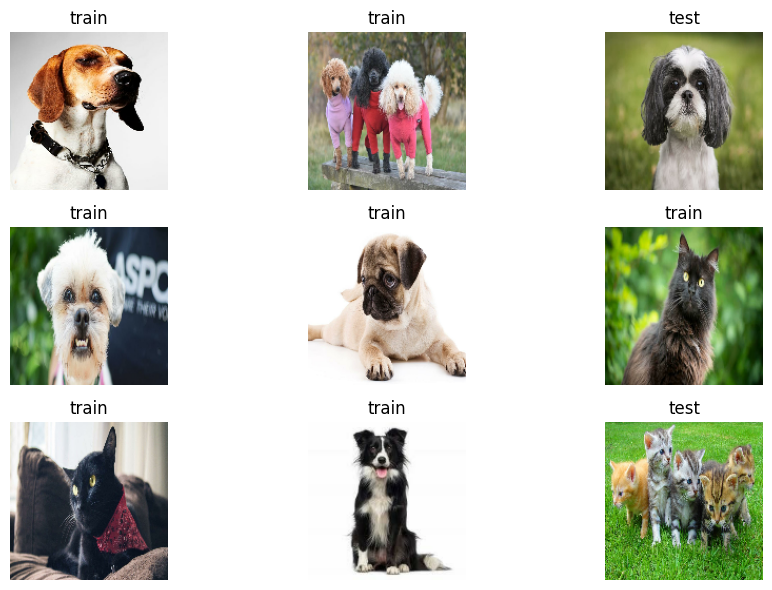

In [ ]:
plt.figure(figsize=(10, 6))

for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i].numpy()])
        plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

normalization_layer = layers.Rescaling(1.0 / 255)

train_ds = train_ds.map(
    lambda images, labels: (normalization_layer(images), labels),
    num_parallel_calls=AUTOTUNE
)

val_ds = val_ds.map(
    lambda images, labels: (normalization_layer(images), labels),
    num_parallel_calls=AUTOTUNE
)

train_ds = train_ds.cache().shuffle(1000, seed=SEED).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)

for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Pixel min:", tf.reduce_min(images).numpy())
    print("Pixel max:", tf.reduce_max(images).numpy())

Image batch shape: (32, 150, 150, 3)
Label batch shape: (32,)
Pixel min: 0.0
Pixel max: 1.0


In [ ]:
weight_decay = 1e-4

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05),
], name="data_augmentation")


def build_cat_dog_cnn(input_shape=(150, 150, 3)):
    inputs = layers.Input(shape=input_shape)

    # Data augmentation chỉ hoạt động khi training
    x = data_augmentation(inputs)

    # Block 1
    x = layers.Conv2D(
        32,
        kernel_size=(3, 3),
        padding="same",
        kernel_regularizer=regularizers.l2(weight_decay)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)

    # Block 2
    x = layers.Conv2D(
        64,
        kernel_size=(3, 3),
        padding="same",
        kernel_regularizer=regularizers.l2(weight_decay)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)

    # Block 3
    x = layers.Conv2D(
        128,
        kernel_size=(3, 3),
        padding="same",
        kernel_regularizer=regularizers.l2(weight_decay)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)

    # Block 4
    x = layers.Conv2D(
        256,
        kernel_size=(3, 3),
        padding="same",
        kernel_regularizer=regularizers.l2(weight_decay)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)

    # Classification head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.35)(x)

    # Binary classification: Cat / Dog
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inputs=inputs, outputs=outputs, name="CatDog_CNN")
    return model


model = build_cat_dog_cnn(input_shape=(150, 150, 3))
model.summary()

Model: "CatDog_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_6 (ReLU)                  │ (None, 150, 150, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_7 (ReLU)                  │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_8 (ReLU)                  │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 18, 18, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_9 (ReLU)                  │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 423,361 (1.61 MB)

 Trainable params: 422,401 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
Dense(1, activation="sigmoid")
loss="binary_crossentropy"

In [ ]:
callbacks = [
    ModelCheckpoint(
        filepath="best_cat_dog_cnn.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    EarlyStopping(
        monitor="val_accuracy",
        patience=8,
        restore_best_weights=True,
        mode="max",
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks
)

Epoch 1/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6801 - loss: 0.7050
Epoch 1: val_accuracy improved from None to 0.76978, saving model to best_cat_dog_cnn.keras

Epoch 1: finished saving model to best_cat_dog_cnn.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 68s 3s/step - accuracy: 0.7581 - loss: 0.6369 - val_accuracy: 0.7698 - val_loss: 0.6636 - learning_rate: 0.0010
Epoch 2/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7692 - loss: 0.5853
Epoch 2: val_accuracy did not improve from 0.76978
18/18 ━━━━━━━━━━━━━━━━━━━━ 54s 3s/step - accuracy: 0.7921 - loss: 0.5572 - val_accuracy: 0.7698 - val_loss: 0.5979 - learning_rate: 0.0010
Epoch 3/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7947 - loss: 0.5321
Epoch 3: val_accuracy did not improve from 0.76978
18/18 ━━━━━━━━━━━━━━━━━━━━ 54s 3s/step - accuracy: 0.8011 - loss: 0.5232 - val_accuracy: 0.7698 - val_loss: 0.5822 - learning_rate: 0.0010
Epoch 4/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8064 - loss: 0.5062

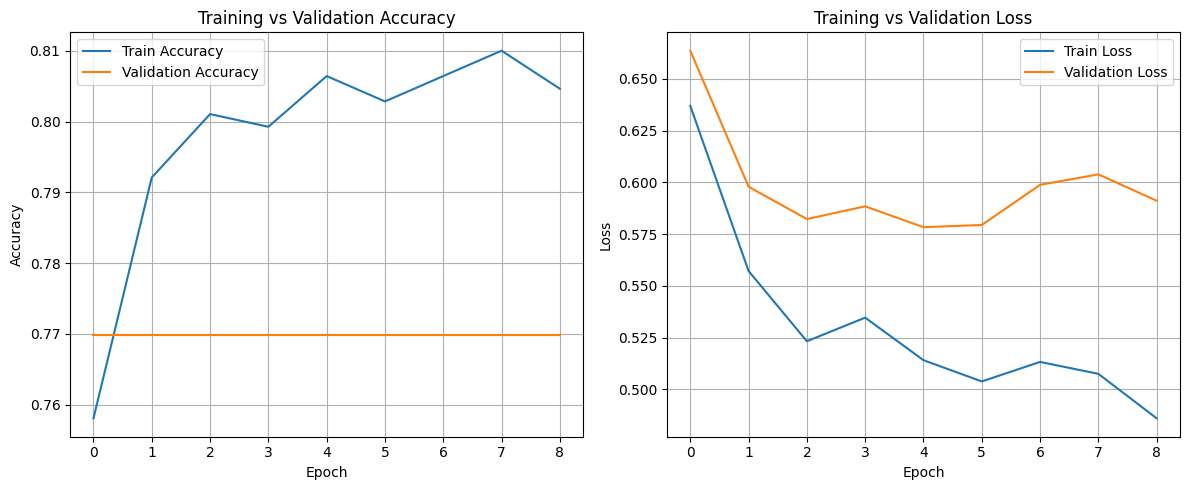

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
y_true = []
y_pred = []
y_prob = []

for images, labels in val_ds:
    probs = model.predict(images, verbose=0).reshape(-1)
    preds = (probs >= 0.5).astype("int32")

    y_true.extend(labels.numpy())
    y_pred.extend(preds)
    y_prob.extend(probs)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

print("y_true shape:", y_true.shape)
print("y_pred shape:", y_pred.shape)

y_true shape: (139,)
y_pred shape: (139,)


In [ ]:
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

        test       0.00      0.00      0.00        32
       train       0.77      1.00      0.87       107

    accuracy                           0.77       139
   macro avg       0.38      0.50      0.43       139
weighted avg       0.59      0.77      0.67       139



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


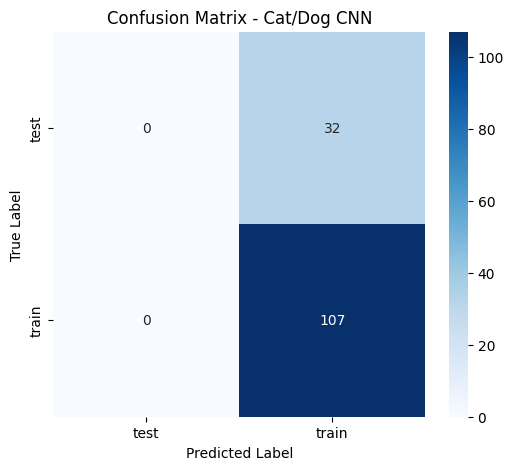

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Cat/Dog CNN")
plt.show()

In [ ]:
from tensorflow.keras.utils import load_img, img_to_array

def predict_cat_dog(image_path, model, class_names, img_size=(150, 150)):
    img = load_img(image_path, target_size=img_size)
    img_array = img_to_array(img)
    img_array = img_array.astype("float32") / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prob_class_1 = model.predict(img_array, verbose=0)[0][0]

    pred_id = 1 if prob_class_1 >= 0.5 else 0
    pred_class = class_names[pred_id]

    confidence = prob_class_1 if pred_id == 1 else 1.0 - prob_class_1

    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Prediction: {pred_class} | Confidence: {confidence:.4f}")
    plt.show()

    return pred_class, confidence

In [ ]:
model.save("cat_dog_cnn.keras")
print("Đã lưu mô hình: cat_dog_cnn.keras")

Đã lưu mô hình: cat_dog_cnn.keras


In [ ]:
loaded_model = tf.keras.models.load_model("cat_dog_cnn.keras", compile=False)

loaded_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

loaded_model.evaluate(val_ds)

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 460ms/step - accuracy: 0.7698 - loss: 0.6636


[0.6635764241218567, 0.769784152507782]

3. Hãy viết chương trình cài đặt CNN để nhận dạng ảnh Fashion-MNIST. Dữ liệu do giảng viên cung
cấp.

In [ ]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

SEED = 42
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: []


In [ ]:
import tensorflow as tf
import numpy as np

# =========================
# LẤY DATASET BẰNG API KERAS
# Không dùng /kaggle/input
# Không dùng file CSV
# =========================

fashion_mnist = tf.keras.datasets.fashion_mnist

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

IMG_SIZE = (28, 28)
BATCH_SIZE = 32
NUM_CLASSES = 10

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

print("x_train:", x_train.shape)
print("y_train:", y_train.shape)
print("x_test :", x_test.shape)
print("y_test :", y_test.shape)

print("Số lớp:", NUM_CLASSES)
print("Tên lớp:", class_names)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train: (60000, 28, 28)
y_train: (60000,)
x_test : (10000, 28, 28)
y_test : (10000,)
Số lớp: 10
Tên lớp: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd

# =========================
# LẤY FASHION-MNIST BẰNG API
# Không dùng /kaggle/input
# Không đọc file CSV
# =========================

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

IMG_SIZE = (28, 28)
BATCH_SIZE = 32
NUM_CLASSES = 10

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

print("x_train:", x_train.shape)
print("y_train:", y_train.shape)
print("x_test :", x_test.shape)
print("y_test :", y_test.shape)
print("Classes:", class_names)

x_train: (60000, 28, 28)
y_train: (60000,)
x_test : (10000, 28, 28)
y_test : (10000,)
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [ ]:
X_train_full = df_train.iloc[:, 1:].values
y_train_full = df_train.iloc[:, 0].values

X_test = df_test.iloc[:, 1:].values
y_test = df_test.iloc[:, 0].values

print("X_train_full:", X_train_full.shape)
print("y_train_full:", y_train_full.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train_full: (20000, 784)
y_train_full: (20000,)
X_test: (10000, 784)
y_test: (10000,)


In [ ]:
X_train_full = X_train_full.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

X_train_full = X_train_full.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print("X_train_full:", X_train_full.shape)
print("X_test:", X_test.shape)

X_train_full: (20000, 28, 28, 1)
X_test: (10000, 28, 28, 1)


In [ ]:
X_train = X_train_full[:54000]
y_train = y_train_full[:54000]

X_val = X_train_full[54000:]
y_val = y_train_full[54000:]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (20000, 28, 28, 1)
y_train: (20000,)
X_val: (0, 28, 28, 1)
y_val: (0,)
X_test: (10000, 28, 28, 1)
y_test: (10000,)


In [ ]:
class_names = [
    "T-shirt/top",  # 0
    "Trouser",      # 1
    "Pullover",     # 2
    "Dress",        # 3
    "Coat",         # 4
    "Sandal",       # 5
    "Shirt",        # 6
    "Sneaker",      # 7
    "Bag",          # 8
    "Ankle boot"    # 9
]

num_classes = 10
input_shape = (28, 28, 1)

print("Number of classes:", num_classes)
print("Input shape:", input_shape)

Number of classes: 10
Input shape: (28, 28, 1)


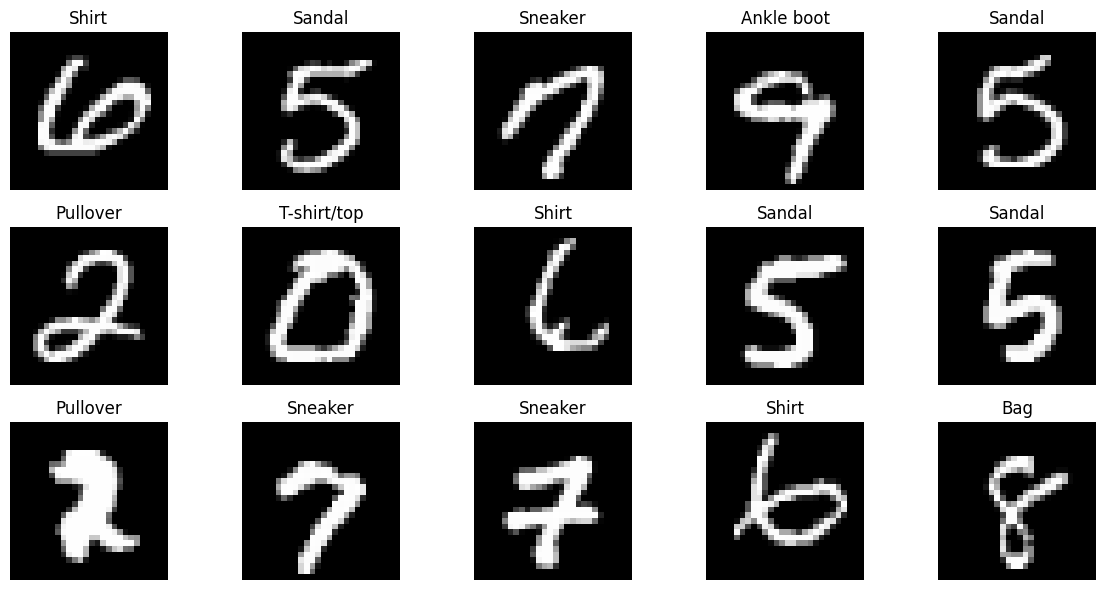

In [ ]:
plt.figure(figsize=(12, 6))

for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(X_train[i].reshape(28, 28), cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
BATCH_SIZE = 64
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))

train_ds = (
    train_ds
    .shuffle(buffer_size=10000, seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    val_ds
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    test_ds
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

In [ ]:
weight_decay = 1e-4

def build_fashion_mnist_cnn(input_shape=(28, 28, 1), num_classes=10):
    inputs = layers.Input(shape=input_shape)

    # Block 1
    x = layers.Conv2D(
        32,
        kernel_size=(3, 3),
        padding="same",
        kernel_regularizer=regularizers.l2(weight_decay)
    )(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(
        32,
        kernel_size=(3, 3),
        padding="same",
        kernel_regularizer=regularizers.l2(weight_decay)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = layers.Dropout(0.25)(x)

    # Block 2
    x = layers.Conv2D(
        64,
        kernel_size=(3, 3),
        padding="same",
        kernel_regularizer=regularizers.l2(weight_decay)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(
        64,
        kernel_size=(3, 3),
        padding="same",
        kernel_regularizer=regularizers.l2(weight_decay)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = layers.Dropout(0.30)(x)

    # Block 3
    x = layers.Conv2D(
        128,
        kernel_size=(3, 3),
        padding="same",
        kernel_regularizer=regularizers.l2(weight_decay)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.GlobalAveragePooling2D()(x)

    # Classification head
    x = layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=regularizers.l2(weight_decay)
    )(x)
    x = layers.Dropout(0.40)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs=inputs, outputs=outputs, name="FashionMNIST_CNN")
    return model


model = build_fashion_mnist_cnn(input_shape=input_shape, num_classes=num_classes)
model.summary()

Model: "FashionMNIST_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)     │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_10 (ReLU)                 │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_11 (ReLU)                 │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_12 (ReLU)                 │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_13 (ReLU)                 │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_14 (ReLU)                 │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        16,51

 Total params: 157,930 (616.91 KB)

 Trainable params: 157,290 (614.41 KB)

 Non-trainable params: 640 (2.50 KB)

In [ ]:
loss="sparse_categorical_crossentropy"

In [ ]:
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# =========================
# COMPILE MODEL TRƯỚC KHI FIT
# =========================

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

callbacks = [
    ModelCheckpoint(
        filepath="best_fashion_mnist_cnn.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    EarlyStopping(
        monitor="val_accuracy",
        patience=8,
        restore_best_weights=True,
        mode="max",
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks
)

Epoch 1/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step - accuracy: 0.5839 - loss: 1.2606
Epoch 1: finished saving model to best_fashion_mnist_cnn.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 140s 407ms/step - accuracy: 0.7870 - loss: 0.7084 - learning_rate: 0.0010
Epoch 2/30


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()
/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/model_checkpoint.py:276: UserWarning: Can save best model only with val_accuracy available.
  if self._should_save_model(epoch, batch, logs, filepath):
/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_accuracy` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)
/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/callback_list.py:171: UserWarning: Learning rate reduction is conditioned on metric `val_loss` which is not available. Available me

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step - accuracy: 0.9525 - loss: 0.2035
Epoch 2: finished saving model to best_fashion_mnist_cnn.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 106s 339ms/step - accuracy: 0.9574 - loss: 0.1899 - learning_rate: 0.0010
Epoch 3/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step - accuracy: 0.9644 - loss: 0.1595
Epoch 3: finished saving model to best_fashion_mnist_cnn.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 141s 337ms/step - accuracy: 0.9692 - loss: 0.1465 - learning_rate: 0.0010
Epoch 4/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step - accuracy: 0.9727 - loss: 0.1311
Epoch 4: finished saving model to best_fashion_mnist_cnn.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 104s 333ms/step - accuracy: 0.9758 - loss: 0.1229 - learning_rate: 0.0010
Epoch 5/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - accuracy: 0.9774 - loss: 0.1205
Epoch 5: finished saving model to best_fashion_mnist_cnn.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 105s 335ms/step - accuracy: 0.9769 - loss: 0.1223 - learning_rate: 0.

KeyboardInterrupt: 

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

In [ ]:
y_pred_prob = model.predict(test_ds)
y_pred = np.argmax(y_pred_prob, axis=1)

print(classification_report(
    y_test,
    y_pred,
    target_names=class_names
))

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Fashion-MNIST Confusion Matrix")
plt.show()

In [ ]:
plt.figure(figsize=(14, 8))

for i in range(20):
    plt.subplot(4, 5, i + 1)

    img = X_test[i].reshape(28, 28)
    true_label = y_test[i]
    pred_label = y_pred[i]
    confidence = np.max(y_pred_prob[i])

    plt.imshow(img, cmap="gray")

    title = (
        f"True: {class_names[true_label]}\n"
        f"Pred: {class_names[pred_label]}\n"
        f"Conf: {confidence:.2f}"
    )

    color = "green" if true_label == pred_label else "red"

    plt.title(title, color=color, fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
model.save("fashion_mnist_cnn.keras")
print("Đã lưu mô hình: fashion_mnist_cnn.keras")

In [ ]:
loaded_model = tf.keras.models.load_model("fashion_mnist_cnn.keras", compile=False)

loaded_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

loaded_model.evaluate(test_ds)